In [1]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Prepare the Images

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [3]:
#Training images loaded

train_data = datagen.flow_from_directory(
    "PetImages",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
   subset="training"
)

Found 11337 images belonging to 2 classes.


In [4]:
# Validation images loaded

validation_data = datagen.flow_from_directory(
    "PetImages",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 2833 images belonging to 2 classes.


In [5]:
# Create CNN

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                input_shape=(128,128,3)))

model.add(MaxPooling2D (pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation= 'relu'))

model.add(MaxPooling2D (pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

C:\Users\NAVTESH\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
print(train_data.class_indices)

{'Cat': 0, 'Dog': 1}


In [9]:
# Train the CNN

history = model.fit(
    train_data,
    validation_data = validation_data,
    epochs=5
)

Epoch 1/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 106s 292ms/step - accuracy: 0.8800 - loss: 0.3889 - val_accuracy: 0.8821 - val_loss: 0.3618
Epoch 2/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 105s 295ms/step - accuracy: 0.8821 - loss: 0.3502 - val_accuracy: 0.8821 - val_loss: 0.3365
Epoch 3/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 104s 292ms/step - accuracy: 0.8822 - loss: 0.3293 - val_accuracy: 0.8821 - val_loss: 0.3119
Epoch 4/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 107s 300ms/step - accuracy: 0.8852 - loss: 0.2991 - val_accuracy: 0.8899 - val_loss: 0.2923
Epoch 5/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 317ms/step - accuracy: 0.8915 - loss: 0.2701 - val_accuracy: 0.8909 - val_loss: 0.3392


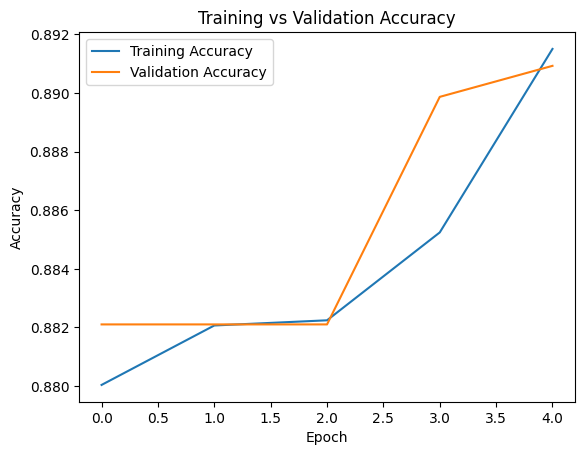

In [10]:
# Training vs Validation Accuracy

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()


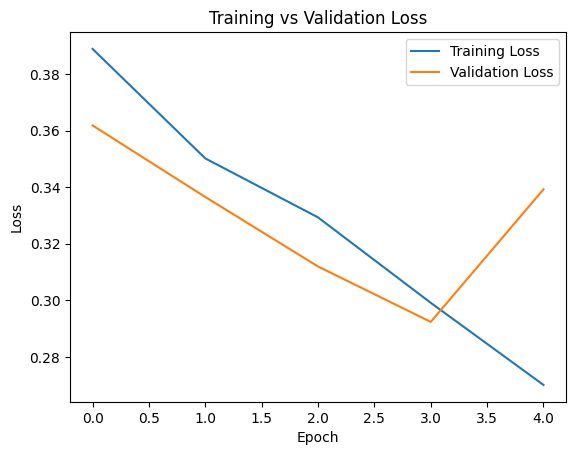

In [11]:
# Training and Validation Loss 
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [12]:
# Training Generator  (Data Augmentation is applied).... validation loss is increasing 

train_datagen = ImageDataGenerator(
    rescale =1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

In [13]:
# Training Data 

train_data = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 11337 images belonging to 2 classes.


In [14]:
# Validation Generator

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [15]:
# Validation Data 

validation_data = validation_datagen.flow_from_directory(
    'PetImages',
    target_size= (128, 128),
    batch_size = 32,
    class_mode = 'binary',
    subset = 'validation'
)

Found 2833 images belonging to 2 classes.


In [16]:
# Create a CNN 

model = Sequential()

model.add(Conv2D(
    32, (3, 3),
    activation="relu",
    input_shape=(128, 128, 3)
))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(
    64, (3, 3),
    activation="relu"
))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_aug = model.fit(
    train_data,
    validation_data = validation_data,
    epochs=5
)

Epoch 1/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 179s 497ms/step - accuracy: 0.8811 - loss: 0.3931 - val_accuracy: 0.8821 - val_loss: 0.3481
Epoch 2/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 176s 494ms/step - accuracy: 0.8821 - loss: 0.3582 - val_accuracy: 0.8821 - val_loss: 0.3424
Epoch 3/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 164s 463ms/step - accuracy: 0.8821 - loss: 0.3474 - val_accuracy: 0.8821 - val_loss: 0.3256
Epoch 4/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 171s 482ms/step - accuracy: 0.8821 - loss: 0.3468 - val_accuracy: 0.8821 - val_loss: 0.3363
Epoch 5/5
355/355 ━━━━━━━━━━━━━━━━━━━━ 169s 477ms/step - accuracy: 0.8820 - loss: 0.3405 - val_accuracy: 0.8821 - val_loss: 0.3531


In [23]:
from tensorflow.keras.preprocessing import image

In [24]:
img = image.load_img('test.jpg' , target_size=(128,128))

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img('test.jpg', target_size=(128, 128))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog🐶 ")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Cat 🐱
